### Angela Johnson

# Employee Turnover Analytics 

In [2]:
# load dataset 
# import library 
import pandas as pd

df = pd.read_csv("HR_comma_sep.csv")

# display first few rows
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
# basic structure 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df.describe(include='all')

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN


In [5]:
# 1 - check for missing values 
# check for missing values in each column
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

* I checked for missing values using df.isna().sum()
* The result shows 0 missing values across all columns
* No imputation or cleaning for missing data is required
* The dataset is complete and ready for further EDA

In [6]:
# 2 — understand factors contributing to employee turnover (EDA)

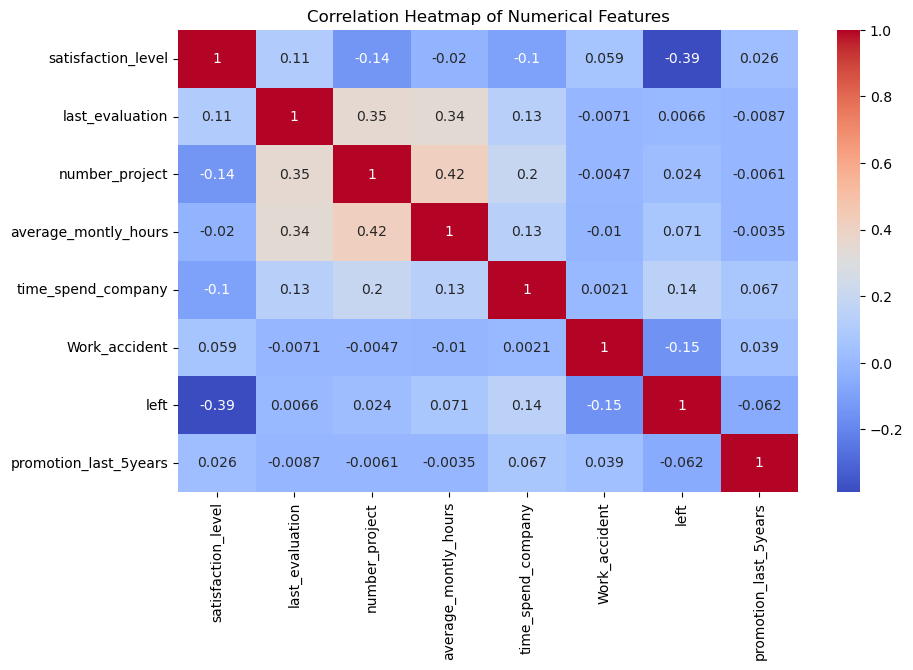

In [7]:
# 2.1 - correlation heatmap for numerical features
import seaborn as sns
import matplotlib.pyplot as plt

# select only numerical columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# compute correlation matrix
corr = numeric_df.corr()

# draw heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

The correlation heatmap shows the relationships between all numerical variables and employee turnover (left). 

Key observations:
* Satisfaction level has the strongest relationship with turnover (–0.39)
    * Employees with lower satisfaction are significantly more likely to leave
* Average monthly hours, number of projects, and time spent in the company show small-to-moderate positive correlations with turnover
    * Employees who work more hours or stay longer may be at slightly higher risk
* Work accident shows a negative correlation with turnover
    * Employees who experienced an accident were actually less likely to leave

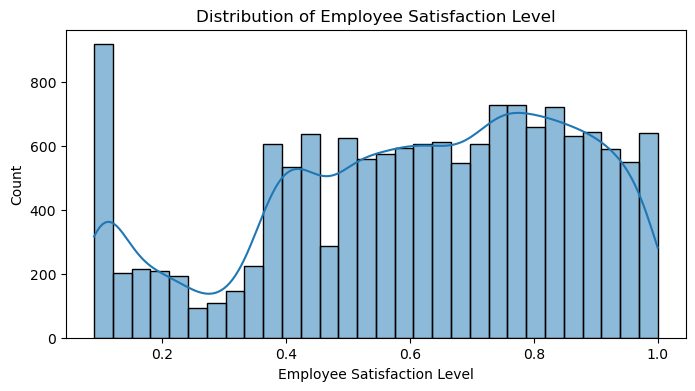

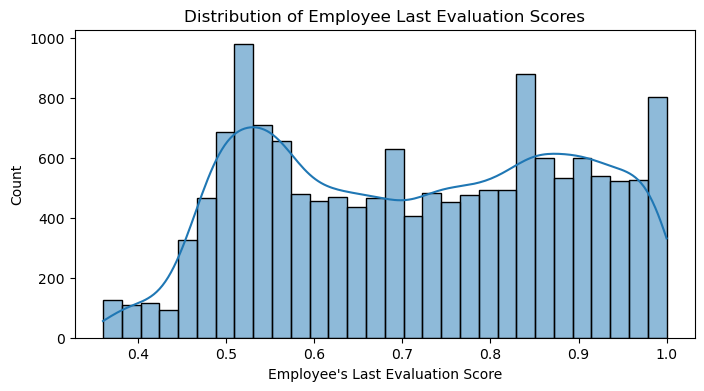

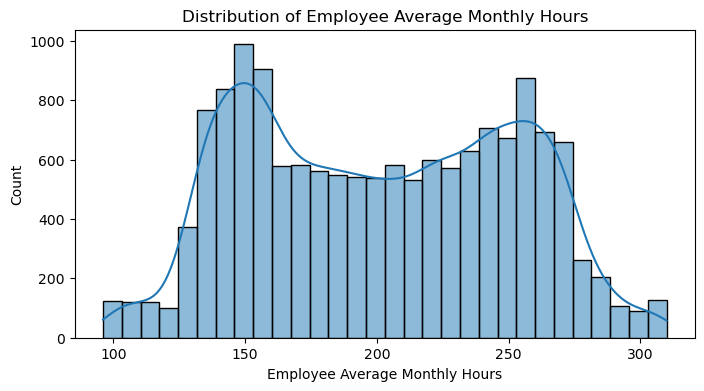

In [9]:
# 2.2 - distribution plots

##### Employee Satisfaction #####
plt.figure(figsize=(8,4))
sns.histplot(df['satisfaction_level'], kde=True, bins=30)
plt.title("Distribution of Employee Satisfaction Level")
plt.xlabel("Employee Satisfaction Level")
plt.ylabel("Count")
plt.show()
print()
##### Employee Last Evaluation ##### 
plt.figure(figsize=(8,4))
sns.histplot(df['last_evaluation'], kde=True, bins=30)
plt.title("Distribution of Employee Last Evaluation Scores")
plt.xlabel("Employee's Last Evaluation Score")
plt.ylabel("Count")
plt.show()
print()
##### Employee Average Monthly Hours ##### 
plt.figure(figsize=(8,4))
sns.histplot(df['average_montly_hours'], kde=True, bins=30)
plt.title("Distribution of Employee Average Monthly Hours")
plt.xlabel("Employee Average Monthly Hours")
plt.ylabel("Count")
plt.show()

**Satisfaction Level**: 
The satisfaction distribution is bimodal, with clusters of very low and very high satisfaction. The large low-satisfaction group suggests a segment of unhappy employees who are more likely to leave.

**Last Evaluation**: 
Evaluation scores are generally high, with many employees scoring between 0.8 and 1.0. A smaller group scores around 0.5–0.6, indicating two distinct performance groups.

**Average Monthly Hours**: 
Monthly working hours show multiple peaks, revealing both normally worked employees (about 150 hours) and heavily overworked employees (about 250 hours). Overworked employees often experience higher turnover.

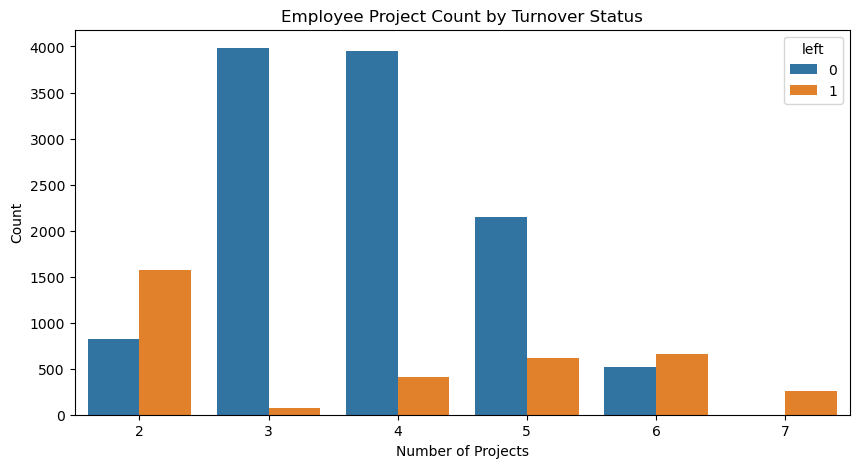

In [10]:
# 2.3 - bar plot —> number of projects vs left

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='number_project', hue='left')
plt.title("Employee Project Count by Turnover Status")
plt.xlabel("Number of Projects")
plt.ylabel("Count")
plt.show()

Employees with 2 projects have a high probability of leaving
* They may be underutilized or disengaged

Employees with 6 or 7 projects also show higher turnover
* This suggests burnout from excessive workload

Employees handling 3, 4, or 5 projects show the lowest turnover
*  This appears to be the optimal workload range for retention

### Inference: 
Both underworked and overworked employees are more likely to leave the organization. The lowest turnover occurs among employees with a moderate and balanced project count (3–5 projects). This suggests that maintaining a fair and manageable workload is a key factor in improving employee retention.

In [11]:
# task 3 — clustering employees who left
# we only cluster employees who left and only use:
# -> satisfaction_level
# -> last_evaluation
# -> left (used only to filter, NOT clustered

In [12]:
# 3.1 - select the colummns & filter employees who left

# select relevant columns
df_cluster = df[['satisfaction_level', 'last_evaluation', 'left']]

# filter only employees who left
df_left = df_cluster[df_cluster['left'] == 1].copy()

# drop the 'left' column (we do not cluster on it)
df_left = df_left[['satisfaction_level', 'last_evaluation']]

df_left.head()

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


In [13]:
# 3.2 - scale the data (important for K-means)
# K-means is distance-based 
# -> scaling prevents one feature from dominating

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_left = scaler.fit_transform(df_left)

In [14]:
# 3.2 - perform K-means clustering (3 clusters)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(scaled_left)

# add cluster labels to dataframe
df_left['cluster'] = clusters

df_left.head()

,satisfaction_level,last_evaluation,cluster
0,0.38,0.53,0
1,0.80,0.86,1
2,0.11,0.88,2
3,0.72,0.87,1
4,0.37,0.52,0


Each row represents an employee who left the company, and the 'cluster' column indicates
which behavioral group they belong to. K-means grouped these employees based on similarity
in satisfaction level and last evaluation. 


* Cluster 0: Employees with low satisfaction and average or low evaluations (likely disengaged employees).

* Cluster 1: Employees with moderate to high satisfaction and high evaluations (strong performers, possibly overworked).

* Cluster 2: Employees with very low satisfaction but very high evaluations (unhappy high performers at highest risk of leaving).

In [15]:
# task 4 — handling class imbalance using SMOTE

In [16]:
# 4.1 - pre-process the data (convert categorical → numerical)

# separate categorical and numeric columns
categorical_cols = df[['sales', 'salary']]
numeric_cols = df.drop(['sales', 'salary'], axis=1)

# convert categorical columns using one-hot encoding
categorical_dummies = pd.get_dummies(categorical_cols, drop_first=True)

# combine numeric + encoded categorical columns
df_processed = pd.concat([numeric_cols, categorical_dummies], axis=1)

df_processed.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [17]:
# 4.2 - stratified train–test split (80:20)
# -> stratification keeps the same left/stay ratio in both sets
from sklearn.model_selection import train_test_split

# features and target
X = df_processed.drop('left', axis=1)
y = df_processed['left']

# 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=123,
    stratify=y # target vairable left is imbalanced
)

# check imbalance in training data
y_train.value_counts()

left
0    9142
1    2857
Name: count, dtype: int64

### Interpreting Train Split Imbalance

Training data currently has:
* left = 0 → 9142 employees stayed  
* left = 1 → 2857 employees left


This is still an imbalanced dataset because:
* Class 0 (stayed) is much larger
* Class 1 (left) is the minority class

Ratio:
* 9142 / 2857 ≈ 3.2 : 1

_For every 1 employee who left, there are about 3 who stayed_

In [18]:
# 4.3 - apply SMOTE to Upsample the Training Set
from imblearn.over_sampling import SMOTE

# initialize SMOTE
smote = SMOTE(random_state=123)

# fit SMOTE on training data only
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# check new balanced class counts
y_train_smote.value_counts()

left
0    9142
1    9142
Name: count, dtype: int64

In [19]:
# task 5 - 5-Fold coss-validation with pipelines + classification reports
# pipline 
# standard scaler 
# LogisticRegression, RandomForestClassifier, GradientBoostingClassifier
# cross_val_predict(cv=5)
# SMOTE data: X_train_smote, y_train_smote


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [20]:
# function for evaluation 

def evaluate_model(model, X, y, model_name):
    # Run 5-fold CV prediction
    y_pred = cross_val_predict(model, X, y, cv=5)

    # Classification Report
    print(f"\n===== {model_name} — Classification Report (5-Fold CV) =====")
    print(classification_report(y, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Stayed (0)', 'Left (1)'],
        yticklabels=['Stayed (0)', 'Left (1)']
    )
    plt.title(f"{model_name} — Confusion Matrix (5-Fold CV)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


===== Logistic Regression — Classification Report (5-Fold CV) =====
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.80     18284
   macro avg       0.80      0.80      0.80     18284
weighted avg       0.80      0.80      0.80     18284



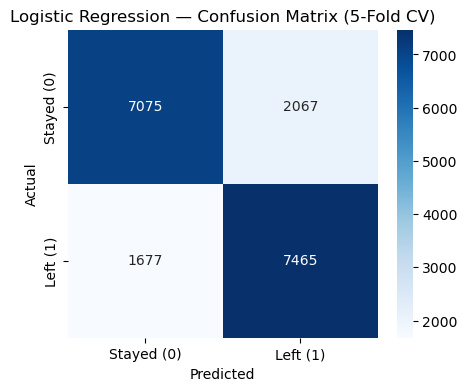

In [22]:
# 5.1 - logistic regression ippeline (cv=5)
log_regression_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=123))
])

evaluate_model(log_regression_pipeline, X_train_smote, y_train_smote, "Logistic Regression")


===== Random Forest — Classification Report (5-Fold CV) =====
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9142
           1       1.00      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284



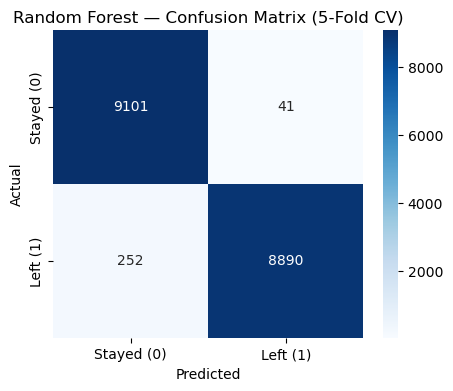

In [23]:
# 5.2 - random forest pipeline (cv=5)

rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=123,
        n_jobs=-1
    ))
])

evaluate_model(rf_pipeline, X_train_smote, y_train_smote, "Random Forest")


===== Gradient Boosting — Classification Report (5-Fold CV) =====
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



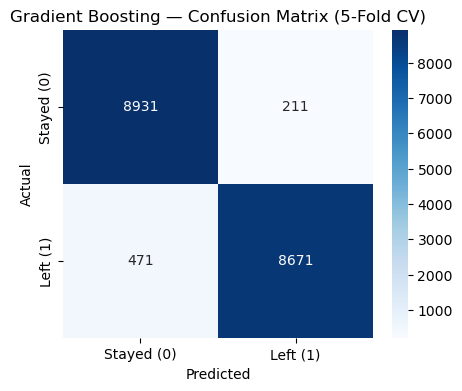

In [24]:
# 5.3 - gradient boosting pipeline (cv=5)
gradboost_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', GradientBoostingClassifier(random_state=123))
])

evaluate_model(gradboost_pipeline, X_train_smote, y_train_smote, "Gradient Boosting")

In [25]:
# task 6 — identify the best model & justify metrics

In [26]:
# using the same pipelines from task 5

In [27]:
# imports 
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [28]:
# helper function for ROC curve 
def plot_roc_curve(model, X, y, model_name):
    # get predicted probabilities using cross_val_predict
    y_prob = cross_val_predict(model, X, y, cv=5, method="predict_proba")[:, 1]
    
    # compute ROC curve
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")
    
    return roc_auc

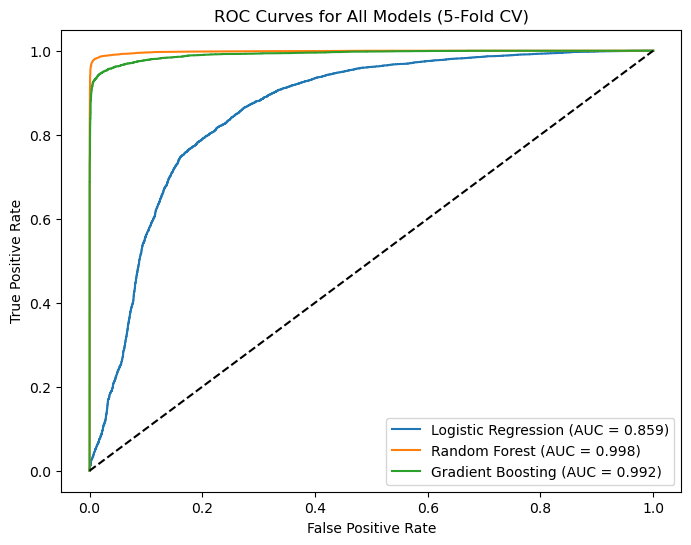

(np.float64(0.8590938081340992),
 np.float64(0.9982201324770063),
 np.float64(0.9922055886652084))

In [31]:
# 6.1 — plot ROC curves for all models
plt.figure(figsize=(8, 6))

auc_lr = plot_roc_curve(log_regression_pipeline, X_train_smote, y_train_smote, "Logistic Regression")
auc_rf = plot_roc_curve(rf_pipeline, X_train_smote, y_train_smote, "Random Forest")
auc_gb = plot_roc_curve(gradboost_pipeline, X_train_smote, y_train_smote, "Gradient Boosting")

# random guess line
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curves for All Models (5-Fold CV)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

auc_lr, auc_rf, auc_gb

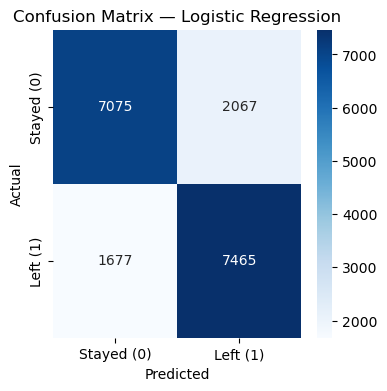

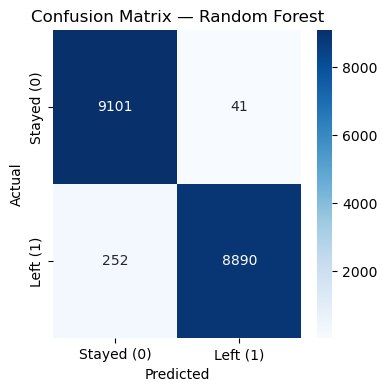

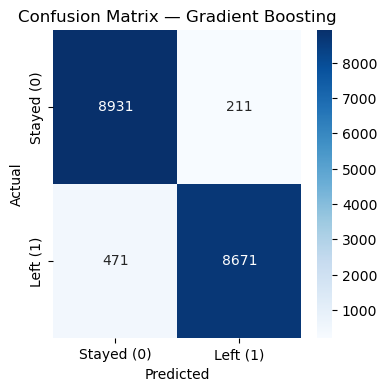

In [33]:
# 6.2 — confusion matrices for ALL models
def plot_conf_matrix(model, X, y, model_name):
    y_pred = cross_val_predict(model, X, y, cv=5)
    cm = confusion_matrix(y, y_pred)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Stayed (0)", "Left (1)"],
                yticklabels=["Stayed (0)", "Left (1)"])
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf_matrix(log_regression_pipeline, X_train_smote, y_train_smote, "Logistic Regression")
plot_conf_matrix(rf_pipeline, X_train_smote, y_train_smote, "Random Forest")
plot_conf_matrix(gradboost_pipeline, X_train_smote, y_train_smote, "Gradient Boosting")

### 6.3 - which metric should be used 

In the context of employee turnover prediction, Recall for the "left" class (class 1) is the most important metric. As Recall measures how many of the employees who are actually leaving the company are correctly identified by the model. Missing an employee who is likely to leave (false negative) is more harmful than incorrectly flagging someone who is staying (false positive), because HR cannot then intervene or apply retention type strategies, especially if the model 
fails to detect at-risk employees. Therefore, Recall for class 1 should be prioritized over Precision.

In [34]:
# task 7 - retention strategy based on predicted turnover risk 

In [36]:
# 7.1 – Predict probability of leaving for each employee in the test set
# -> using the best model (Random Forest pipeline) trained in previous tasks

y_test_prob = cross_val_predict(
    rf_pipeline, 
    X_test, 
    y_test, 
    cv=5,
    method="predict_proba"
)[:, 1]  # probability of class 1 (left)


# attaching probablities to dataset 
test_results = X_test.copy()
test_results['true_left'] = y_test
test_results['leave_probability'] = y_test_prob

test_results.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,true_left,leave_probability
10627,0.98,0.77,3,191,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0,0.000
2703,0.76,0.93,3,271,5,0,0,False,False,True,False,False,False,False,False,False,True,False,0,0.395
6059,0.70,0.93,3,185,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0,0.010
3258,0.48,0.61,3,223,3,1,0,False,False,False,False,False,False,False,True,False,False,True,0,0.005
4565,0.57,0.90,3,144,2,0,0,False,False,False,False,False,False,False,False,False,False,True,0,0.010


In [37]:
# 7.2 - categorize employee into risk zones

def categorize_zone(prob):
    if prob < 0.20:
        return "Safe Zone (Green)"
    elif prob < 0.60:
        return "Low-Risk Zone (Yellow)"
    elif prob < 0.90:
        return "Medium-Risk Zone (Orange)"
    else:
        return "High-Risk Zone (Red)"

test_results['risk_zone'] = test_results['leave_probability'].apply(categorize_zone)

test_results[['true_left', 'leave_probability', 'risk_zone']].head()

# checking counts
print('===== checking counts =====')
test_results['risk_zone'].value_counts()

===== checking counts =====


risk_zone
Safe Zone (Green)            2253
High-Risk Zone (Red)          547
Medium-Risk Zone (Orange)     121
Low-Risk Zone (Yellow)         79
Name: count, dtype: int64

Based on the predicted turnover probablites:


A majority of employees fall into the Safe Zone (Green) (2253 employees), showing that most employees are stable and not likely to leave. However, a large number—547 employees—are in the High-Risk Zone (Red), meaning they show strong patterns associated with past leavers, such as low satisfaction or high workload. These employees are going to require immediate HR attention to prevent potential turnover. 

Additionally, 121 employees fall into the Medium-Risk Zone (Orange) and may be experiencing early warning signs of dissatisfaction or burnout, suggesting the need for closer monitoring and targeted support, to prevent them entering the High-Risk Zone. 

The Low-Risk Zone (Yellow) contains 79 employees, who are not in immediate danger of leaving but would still benefit from engagement and development efforts to avoid escalation and dissatisfaction. Ultimately, the model highlights a clear priority: focus resources on the high- and medium-risk groups to mitigate turnover and improve organizational stability.